Below contains the code used for the group project

In [24]:
# initial import of libraries
# import more libraries when necessary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# load data
df = pd.read_csv('Concrete_Compressive_Strength.csv')
# set dependent/independent variables
target = "Concrete compressive strength " # there is a space in the original dataset, don't remove it
X = df.drop(columns=[target],inplace=False)
y = df[target]

# Exploratory Data Analysis (EDA) #

In [26]:
# summary data
print("==== Data Head ====")
print(df.head(), "\n")

print("==== Data Info ====")
print(df.info(), "\n")

print("==== Missing Values ====")
print(df.isnull().sum(), "\n")

print("==== Summary Statistics ====")
print(df.describe(), "\n")

==== Data Head ====
   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age (day)  Concrete compressive strength   
0            1040.0           676.0         28                       79.986111  
1            1055.0           676.0         28                       61.887366  
2             932.0           594.0        270                       40.269535  
3             932.0           594.0        365                       41.052780  
4             978.4           825.5        360                       44.296075   

==== Data Info ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 

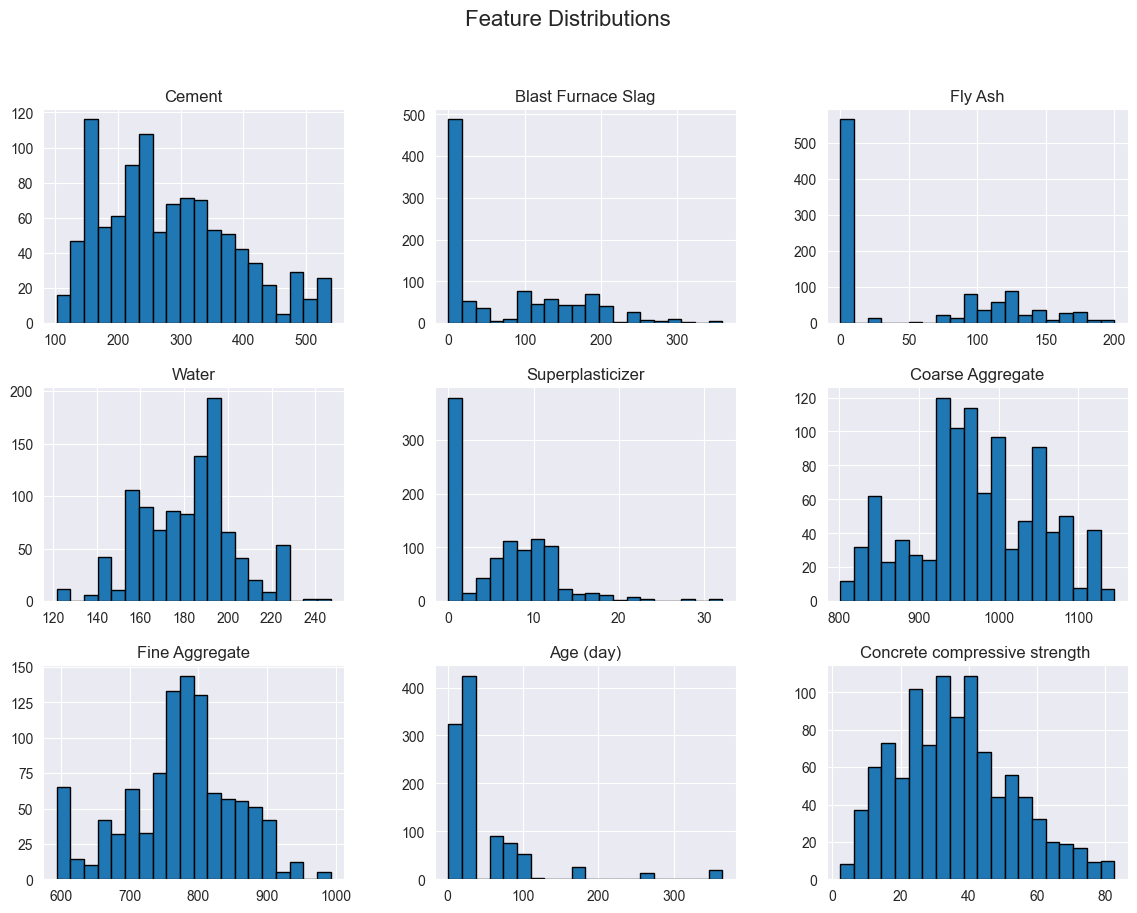

In [27]:
 # Histograms
df.hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

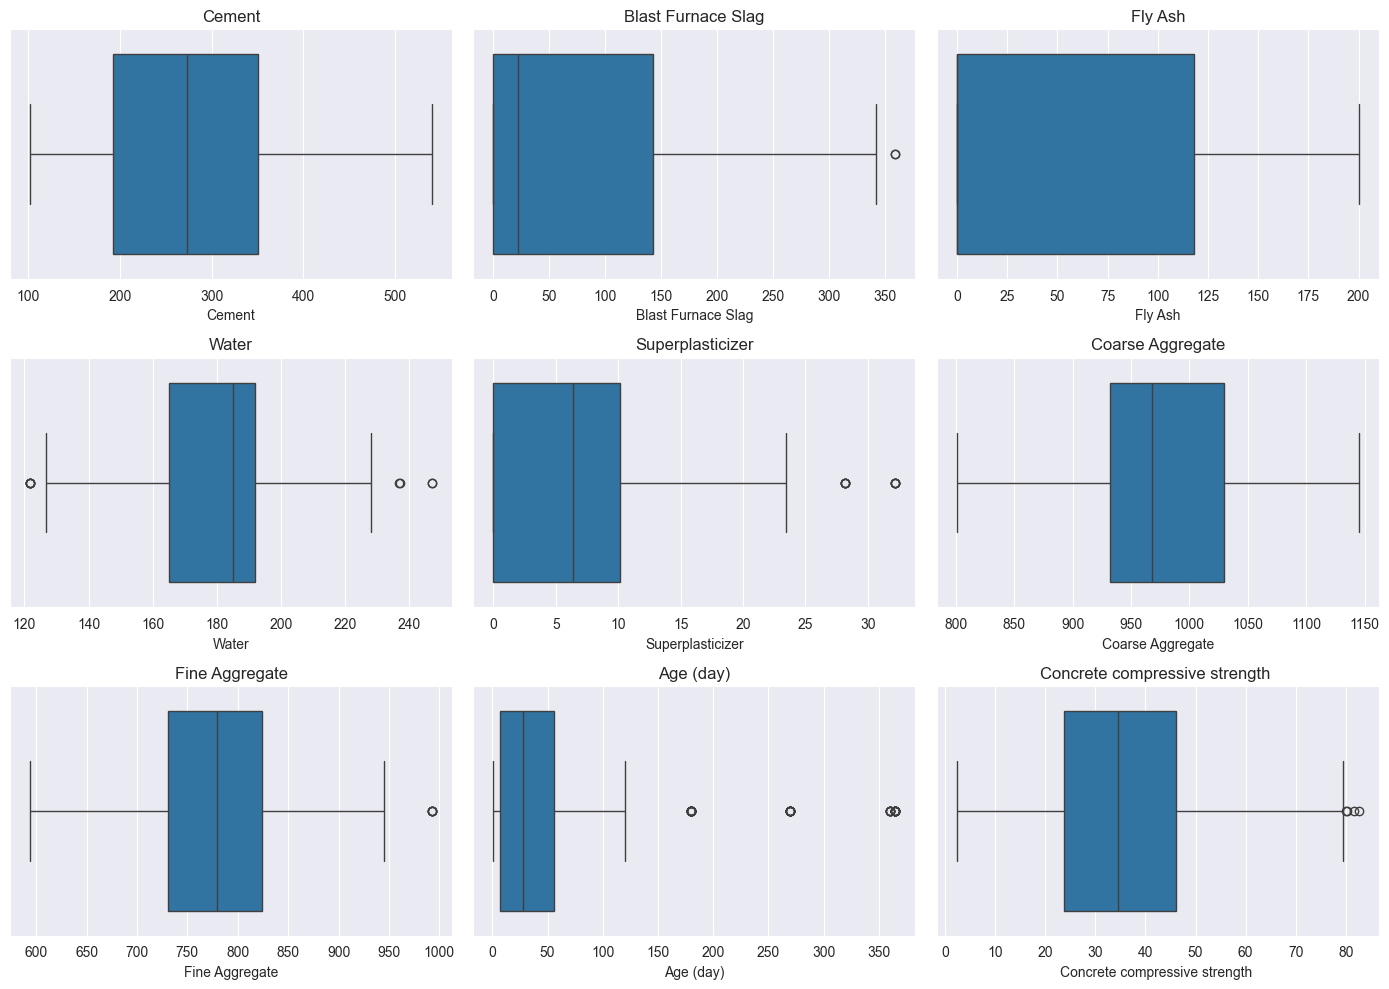

In [28]:
# Box plots （for distributions, outlier etc)
plt.figure(figsize=(14, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

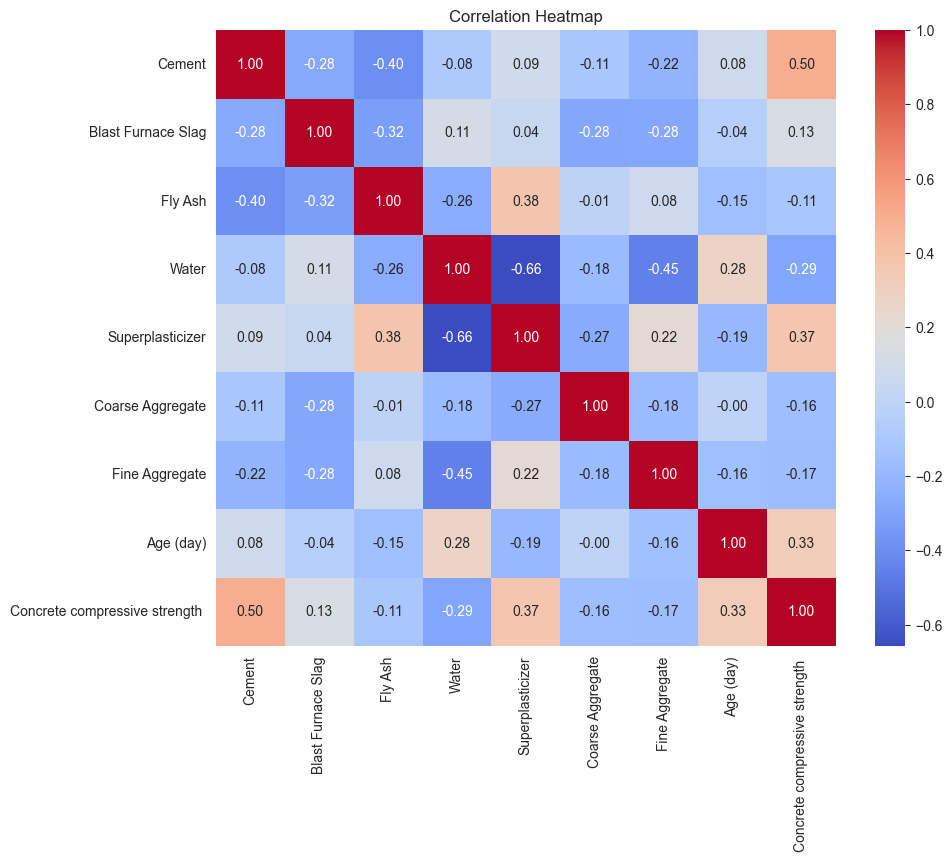

In [29]:
# correlation matrix
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

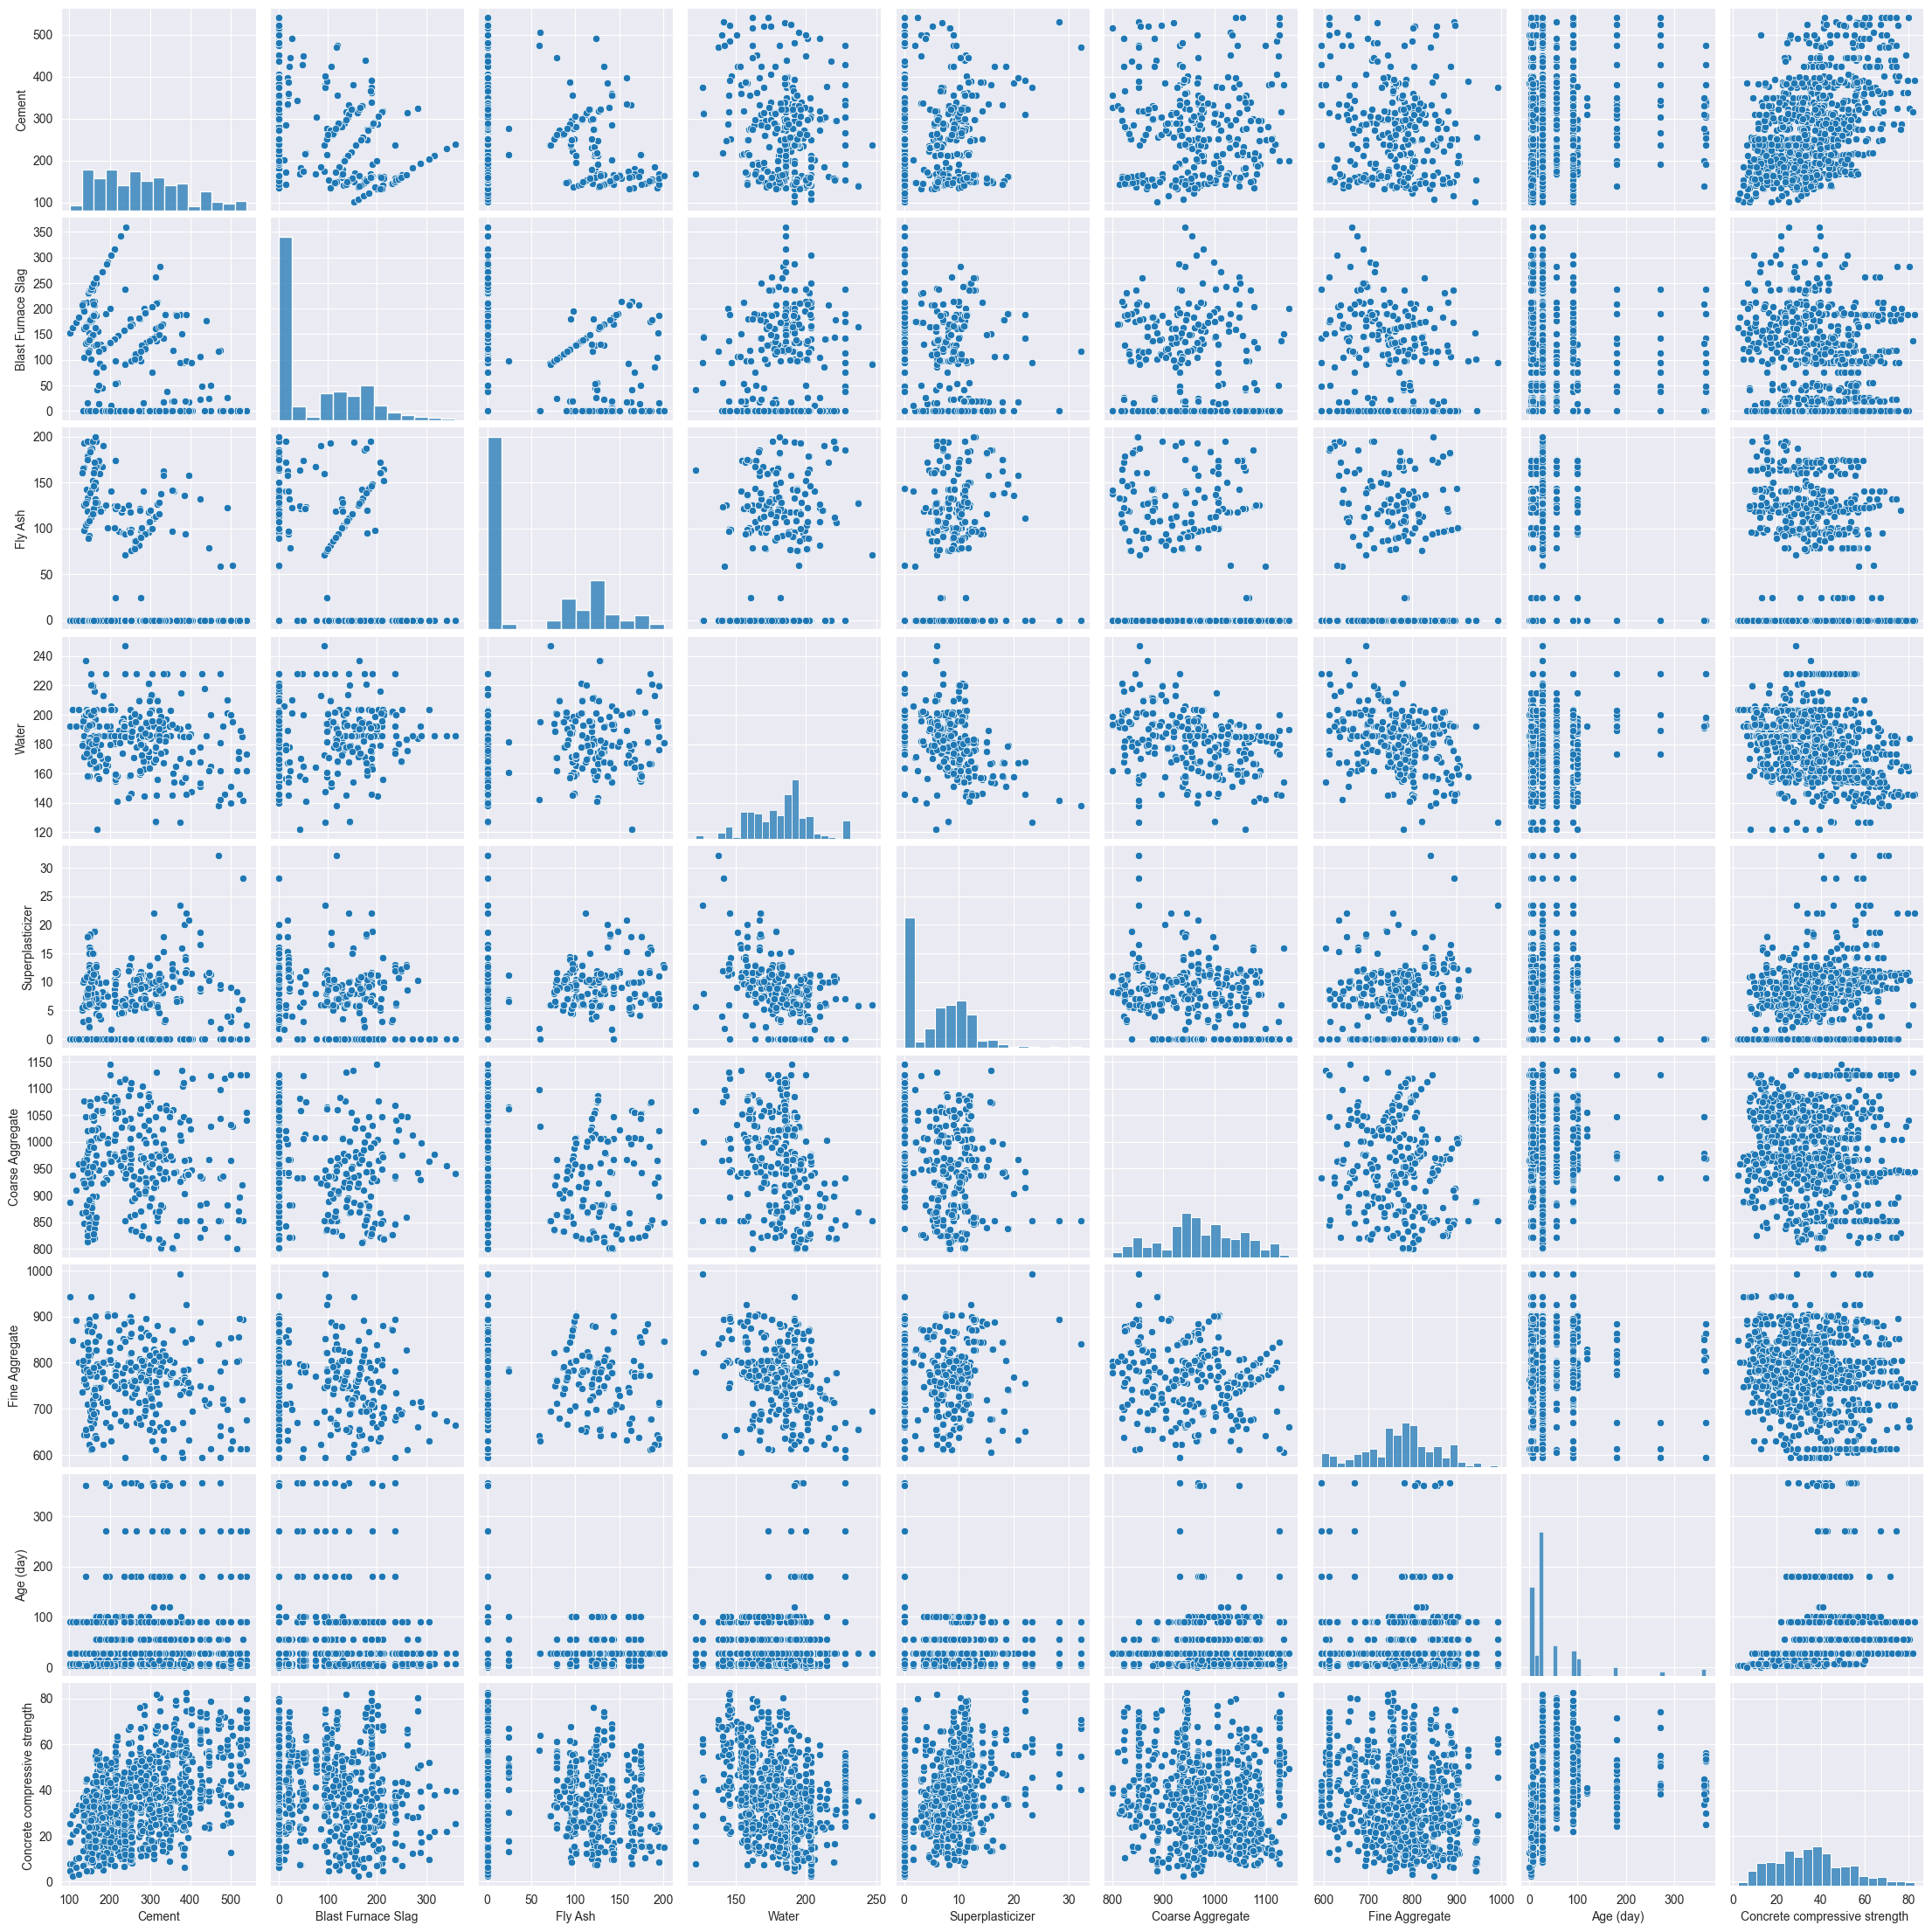

In [30]:
# Paired scatter plots
sns.pairplot(df)
plt.show()

# Regression related (linear, polynomial, ridge, lasso) #

In [31]:
# libraries for regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

In [32]:
# Plotting helpers
# Since it is likely each model has its plotting requirements, this reuses code
# Q-Q plot helper method (used after the model is fit)
#TODO
# Merge the two helper funuctions
def qq_plot(residuals, title):
    plt.figure(figsize=(7, 5))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(title)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True)
    plt.show()

def qq_plot2(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(7, 5))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(title)
    plt.grid(True)
    plt.show()

# for residual plots
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(title)
    plt.grid(True)
    plt.show()

# for actual vs predicted
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([min(y_true), max(y_true)],
             [min(y_true), max(y_true)], '--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [33]:
# tarin/test split. Current using 80/20, change if necessary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

==== Linear Regression (Scaled) ====
R²: 0.6275416055417096
MSE: 95.97548435260981


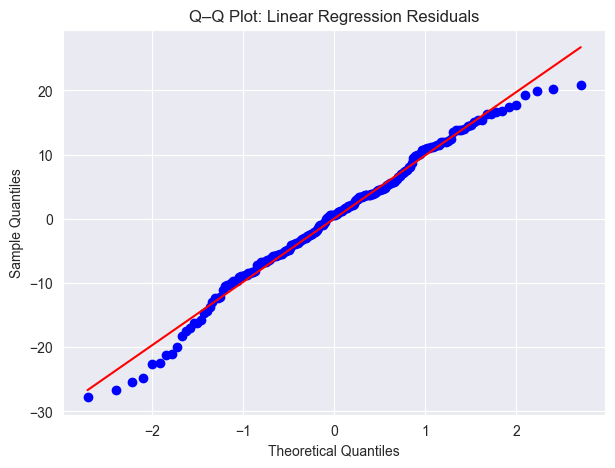

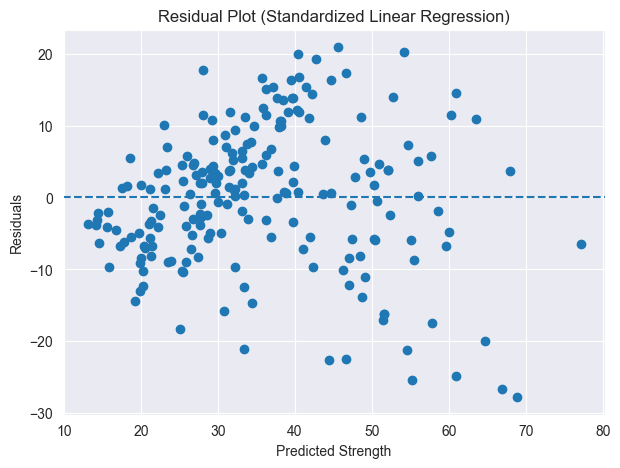

In [34]:
# Linear Regression, scaled
# use MinMaxScaler() if want 0-1
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_test)

print("==== Linear Regression (Scaled) ====")
print("R²:", r2_score(y_test, y_pred_linear))
print("MSE:", mean_squared_error(y_test, y_pred_linear))


# QQ plot
residuals_linear = y_test - y_pred_linear
qq_plot(residuals_linear, "Q–Q Plot: Linear Regression Residuals")


# residuals for Linear regression.
# if want plot for other regressions, edit or copy this block
residuals = y_test - y_pred_linear

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_linear, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Strength")
plt.ylabel("Residuals")
plt.title("Residual Plot (Standardized Linear Regression)")
plt.grid(True)
plt.show()

==== Polynomial Regression (Degree 2, Scaled) ====
R²: 0.7842685049663733
MSE: 55.589926375746074


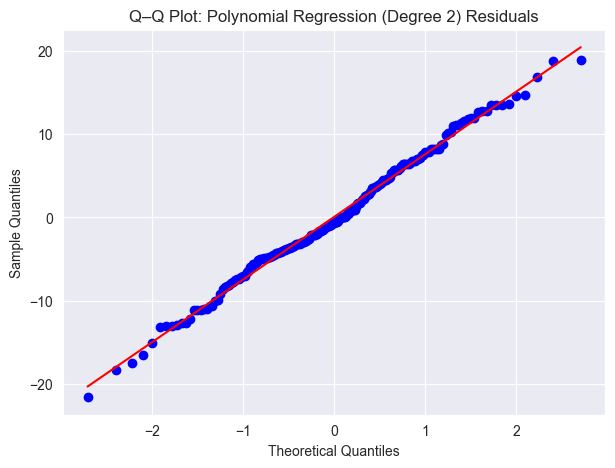

In [35]:
# Polynomial Regression (degree = 2)
# use MinMaxScaler() if want 0-1
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

print("==== Polynomial Regression (Degree 2, Scaled) ====")
print("R²:", r2_score(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))

# QQ plot
residuals_poly = y_test - y_pred_poly
qq_plot(residuals_poly, "Q–Q Plot: Polynomial Regression (Degree 2) Residuals")

==== Ridge Regression (Scaled) ====
R²: 0.6275641808571331
MSE: 95.96966712076747


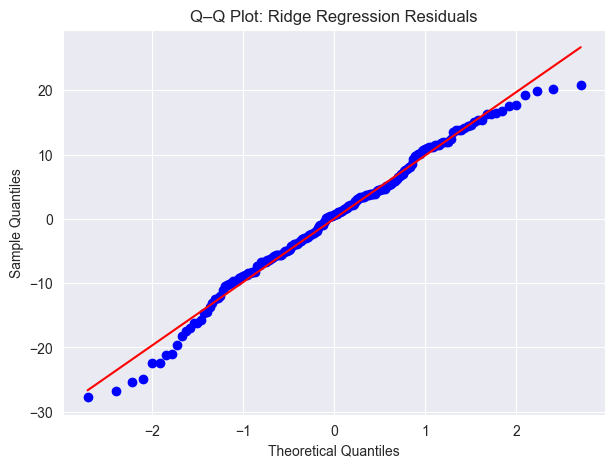

In [36]:
# ridge regression
# use MinMaxScaler() if want 0-1
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

print("==== Ridge Regression (Scaled) ====")
print("R²:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

# QQ plot
residuals_ridge = y_test - y_pred_ridge
qq_plot(residuals_ridge, "Q–Q Plot: Ridge Regression Residuals")

==== Lasso Regression (Scaled) ====
R²: 0.6275448667106976
MSE: 95.9746440110365


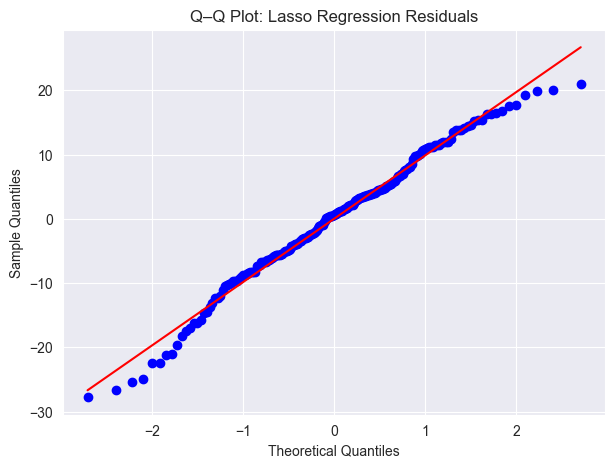

In [37]:
# lasso regression
# use MinMaxScaler() if want 0-1
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.01, max_iter=5000))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

print("==== Lasso Regression (Scaled) ====")
print("R²:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))

# QQ plot
residuals_lasso = y_test - y_pred_lasso
qq_plot(residuals_lasso, "Q–Q Plot: Lasso Regression Residuals")

# Random Forest and Gradient Boosting #

In [38]:
# libraries for these two algorithms
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import shap
shap.initjs()

C:\Users\10184\PycharmProjects\ENGG680\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
# fit model for RF and GBM
rf = RandomForestRegressor(n_estimators=300, random_state=42)
gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=3, random_state=42)

rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

y_rf = rf.predict(X_test)
y_gbm = gbm.predict(X_test)

In [40]:
# Helpers
# feature importance plot
def feature_importance_plot(model, X, title):
    importance = model.feature_importances_
    idx = np.argsort(importance)[::-1]
    plt.figure(figsize=(7, 5))
    plt.bar(range(len(importance)), importance[idx])
    plt.xticks(range(len(importance)), X.columns[idx], rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# SHAP
def shap_analysis(model, X_train, X_test, title):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    print(f"===== SHAP Summary: {title} =====")
    shap.summary_plot(shap_values, X_test, plot_type="bar")
    shap.summary_plot(shap_values, X_test)

    # Single prediction example (first test sample)
    shap.force_plot(explainer.expected_value,
                    shap_values[0,:],
                    X_test.iloc[0,:])


In [41]:
def model_report(name, y_true, y_pred):
    print(f"==== {name} ====")
    print("R²:", r2_score(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print()

model_report("Random Forest", y_test, y_rf)
model_report("Gradient Boosting", y_test, y_gbm)

==== Random Forest ====
R²: 0.8794020533370009
MSE: 31.075810117652466

==== Gradient Boosting ====
R²: 0.9009166526108278
MSE: 25.531904766932634



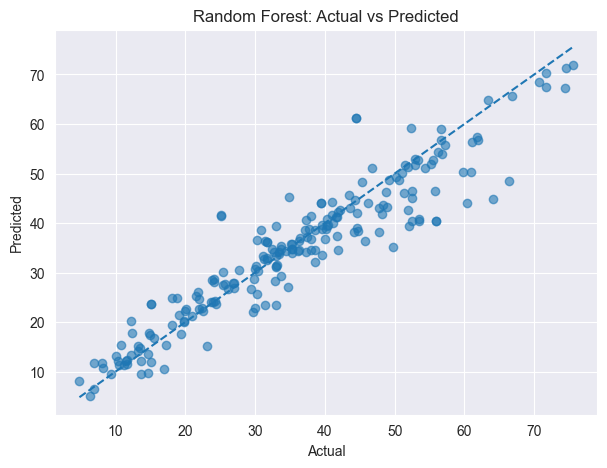

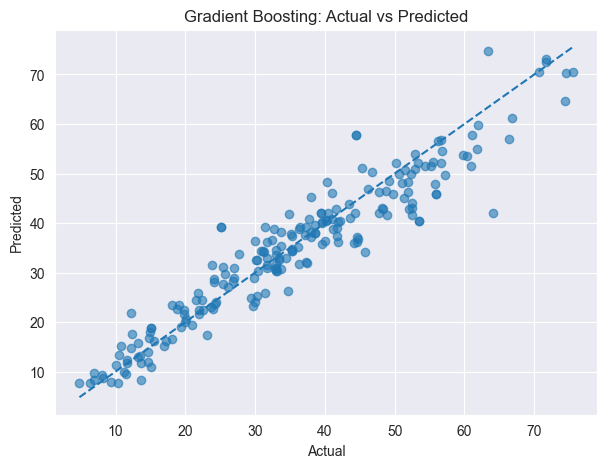

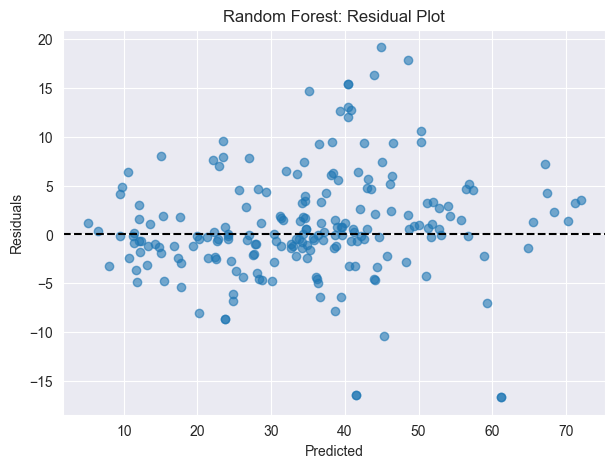

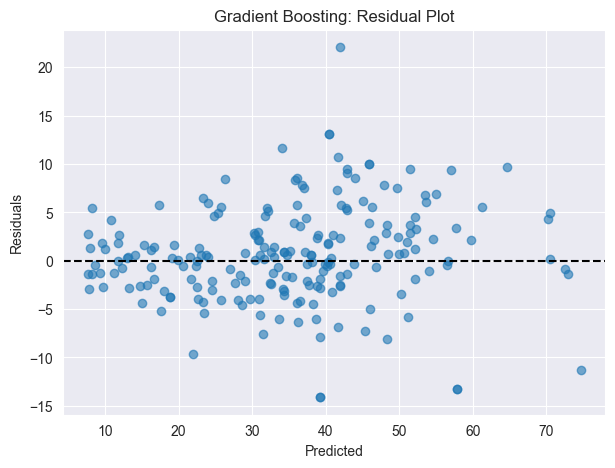

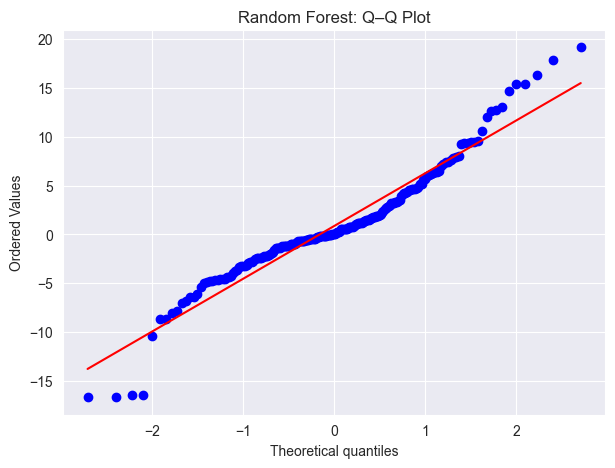

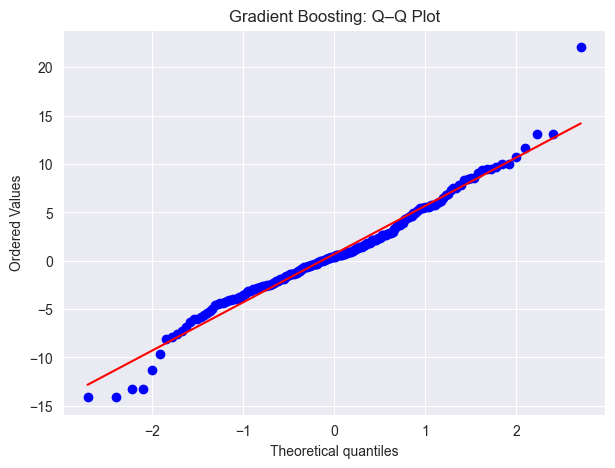

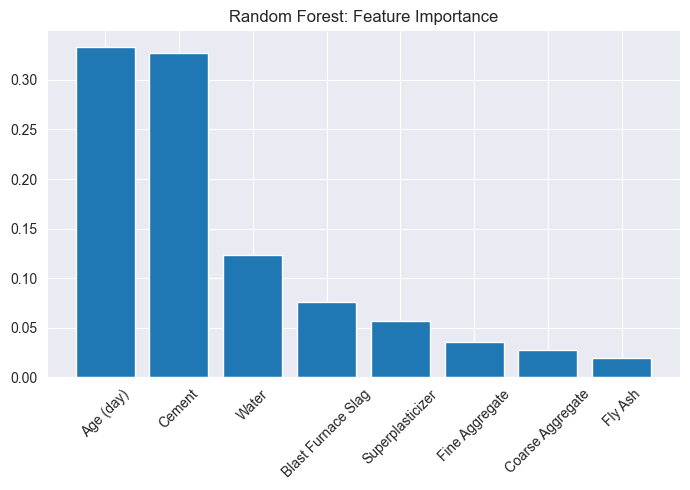

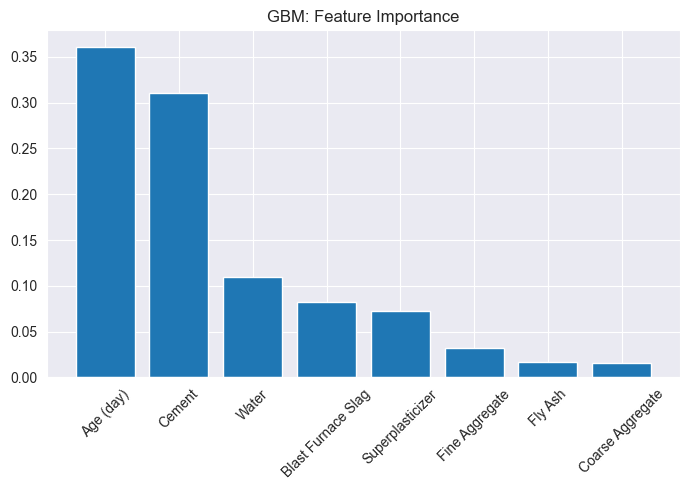

===== SHAP Summary: Random Forest SHAP Analysis =====


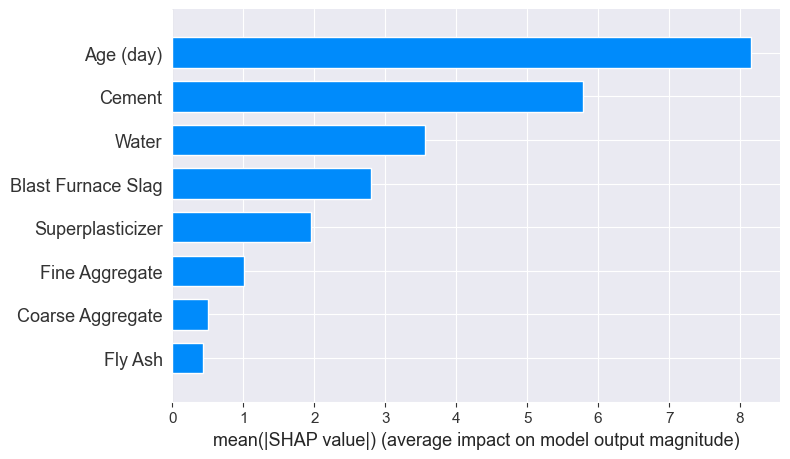

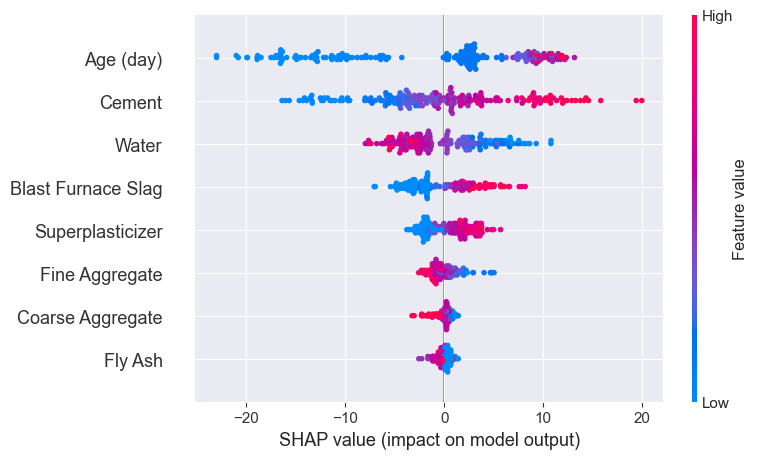

===== SHAP Summary: Gradient Boosting SHAP Analysis =====


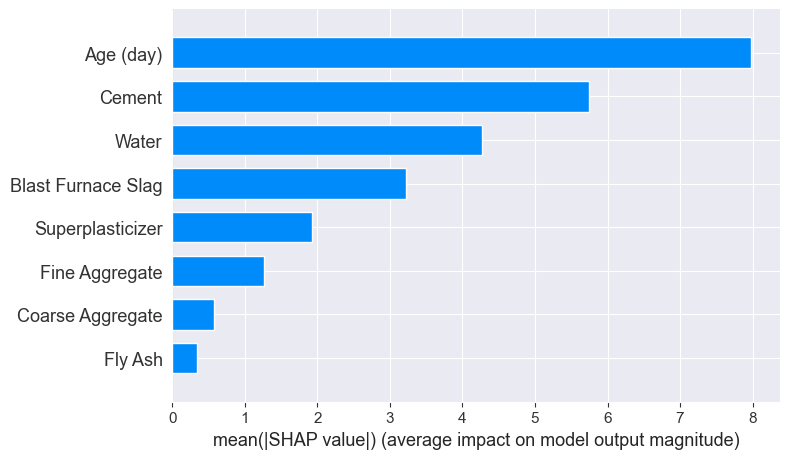

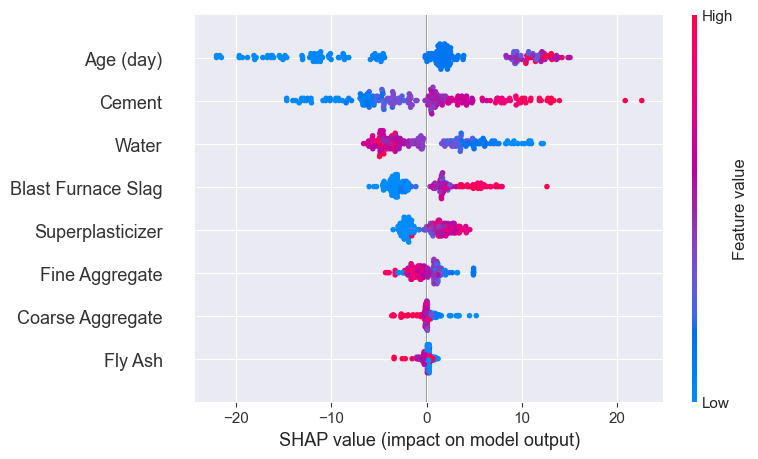

In [42]:
# ---- Actual vs Predicted ----
plot_actual_vs_predicted(y_test, y_rf, "Random Forest: Actual vs Predicted")
plot_actual_vs_predicted(y_test, y_gbm, "Gradient Boosting: Actual vs Predicted")

# ---- Residuals ----
plot_residuals(y_test, y_rf, "Random Forest: Residual Plot")
plot_residuals(y_test, y_gbm, "Gradient Boosting: Residual Plot")

# ---- Q–Q Plots ----
qq_plot2(y_test, y_rf, "Random Forest: Q–Q Plot")
qq_plot2(y_test, y_gbm, "Gradient Boosting: Q–Q Plot")

# ---- Feature Importance ----
feature_importance_plot(rf, X, "Random Forest: Feature Importance")
feature_importance_plot(gbm, X, "GBM: Feature Importance")

# ---- SHAP Values ----
shap_analysis(rf, X_train, X_test, "Random Forest SHAP Analysis")
shap_analysis(gbm, X_train, X_test, "Gradient Boosting SHAP Analysis")

SHAP analysis indicates the same results as previous researchers did before

# hyperparameter tuning #

In [43]:
rf_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# To run:
rf_search.fit(X_train, y_train)
print("Best Params RF:", rf_search.best_params_)

Best Params RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
